In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from tqdm import trange
from scipy.optimize import brentq
from gaia_cmd_plotter.gaia_cmd_axis import GaiaCMDAxis

import numpy as np
from astroquery.gaia import Gaia

import pandas as pd

import matplotlib as mpl

from scipy.stats import gaussian_kde

import matplotlib.gridspec as gridspec

from matplotlib.patches import Rectangle

rsun = 6.96e10
G = 6.67e-8
msun = 1.989e33
yr_to_sec = 3.154e7

mpl.rcParams.update(
     {# Use mathtext, not LaTeX
     'text.usetex': False,
     'axes.formatter.use_mathtext': True,
     # Set the fonts
     'font.family': 'STIXGeneral',
     'mathtext.fontset': 'cm',
     # Use ASCII minus
     'axes.unicode_minus': False,
    'axes.linewidth':1.5
})


%matplotlib inline

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
source_id = 3499149202247569536

query = f"""
select * from gaiadr3.nss_two_body_orbit as phot where phot.source_id in (3499149202247569536))
"""

job = Gaia.launch_job_async(query)
result = job.get_results()[0]

INFO: Query finished. [astroquery.utils.tap.core]


In [3]:
columns_values = ['ra', 'dec', 'parallax', 'pmra', 'pmdec', 'a_thiele_innes', 'b_thiele_innes', 
                  'f_thiele_innes', 'g_thiele_innes', 'eccentricity', 'period', 't_periastron']

columns_errors = ['ra_error', 'dec_error', 'parallax_error', 'pmra_error', 
                  'pmdec_error', 'a_thiele_innes_error', 'b_thiele_innes_error', 
                  'f_thiele_innes_error', 'g_thiele_innes_error', 
                  'eccentricity_error', 'period_error', 't_periastron_error']

mu_vec_BH1 = []
err_vec_BH1= []

for (col1, col2) in zip(columns_values, columns_errors):
    
    mu_vec_BH1.append(result[col1])
    err_vec_BH1.append(result[col2])

corr_vec_BH1 = result['corr_vec']

In [4]:
# convert the correlation matrix to a covariance matrix

Nparam = 12
triangle_nums = (np.arange(1, Nparam)*(np.arange(1, Nparam) - 1)//2)

cov_mat_BH1 = []
count = 0
for i, sigx in enumerate(err_vec_BH1):
    this_row = []
    for j, sigy in enumerate(err_vec_BH1):
        if i == j:
            this_row.append(err_vec_BH1[i]**2)
        elif j < i:
            this_row.append(cov_mat_BH1[j][i])
        else:
            this_idx = triangle_nums[j-1] + i
            this_row.append(corr_vec_BH1[this_idx]*sigx*sigy)
    cov_mat_BH1.append(this_row)
cov_mat_BH1 = np.array(cov_mat_BH1)


In [5]:
# functions to predict RVs at a given time
def fsolve_newton(Mi, ecc, xtol = 1e-10):
    '''
    numerically solve with newton's method.
    Mi: float, 2*pi/P*(t - T_p)
    ecc: float, eccentricity
    xtol: float, tolerance
    '''
    eps = 1
    EE = Mi + ecc*np.sin(Mi) + ecc**2/2*np.sin(2*Mi) + ecc**3/8*(3*np.sin(3*Mi) - np.sin(Mi))
    while eps > xtol:
        EE0 = EE
        EE = EE0 + (Mi + ecc*np.sin(EE0) - EE0)/(1 - ecc*np.cos(EE0))
        eps = np.abs(EE0 - EE) 
    return EE

def solve_kep_eqn(t, T_p, P, ecc):
    '''
    Solve Keplers equation E - e*sin(E) = M for E
    Here, M = 2*pi/P*(t - T_p)
    t: array of times
    T_p: float; periastron time
    P: float, period 
    ecc: float, eccentricity
    '''
    M = 2*np.pi/P * (t - T_p)
    E = np.zeros(t.shape)
    for i,Mi in enumerate(M):
        E[i] = fsolve_newton(Mi = Mi, ecc = ecc, xtol = 1e-10)
    return E

def photocenter_orbit_2d_from_thiele_innes(t_ast_yr, parallax, period, ecc, Tp, A, B, F, G):
    '''
    this function calculates the part of a binary's astrometric motion that is due to the orbit, without parallax and proper motion. 
    t_ast_yr: times relative to reference epoch
    parallax: 1/distance; only used to calculate angular size of the orbit
    period: orbital period in days
    ecc: eccentricity 
    A,B,F,G: Thiele-Innnes elements, in mas
    c_funcs: from read_in_C_functions()
    '''
    EE = solve_kep_eqn(t_ast_yr*365.25, T_p = Tp, P = period, ecc = ecc)
    X, Y = np.cos(EE) - ecc,  np.sqrt(1-ecc**2)*np.sin(EE)
    x, y = B*X + G*Y, A*X + F*Y       
    return x, y

def get_radial_velocities(t, P, T_p, ecc, K, omega, gamma):
    '''
    t: array of times
    P: float, period
    T_p: float, periastron time
    ecc: float, eccentricity
    K: float, RV semi-amplitude
    omega: float, longitude of periastron (radians, not degrees)
    gamma: float, center-of-mass RV
    '''
    E = solve_kep_eqn(t = t, T_p = T_p, P = P, ecc = ecc)
    f = 2*np.arctan2(np.sqrt(1+ecc)*np.sin(E*.5),np.sqrt(1-ecc)*np.cos(E*.5))
    vr = K*(np.cos(f + omega) + ecc*np.cos(omega)) + gamma
    return vr

In [6]:
# likelihood for joint fit of astrometry and RVs


def get_a0_mas(period, m1, m2, parallax):
    '''
    predicts a0 (photocenter semi-major axis) in milliarcsec, 
    assuming a dark companion
    period: float, days
    m1: float, Msun, (mass of luminous star)
    m2: float, Msun, (mass of companion)
    parallax: float, milliarcsec
    '''
    G = 6.6743e-11 # SI units
    Msun = 1.98840987069805e+30
    AU = 1.4959787e+11
    a_au = (((period*86400)**2 * G * (m1*Msun + m2*Msun)/(4*np.pi**2))**(1/3.))/AU
    a_mas = a_au*parallax
    q = m2/m1
    #a0_mas = a_mas*q/(1+q)
    a0_mas = a_mas*(q/(1+q) - 0.009/(1+0.009))
    return a0_mas

def get_Kstar_kms(period, inc_deg, m1, m2, ecc):
    '''
    RV semi-amplitude of the luminous star
    period: float, days
    inc_deg: float, inclination in degrees
    m1: float, mass of luminous star in Msun
    m2: float, mass of companion in Msun
    ecc: float, eccentricity
    '''
    G = 6.6743e-11 # SI units
    Msun = 1.98840987069805e+30
    Kstar = (2*np.pi*G*(m2*Msun) * (m2/(m1 + m2))**2 * np.sin(inc_deg*np.pi/180)**3 / \
             (period*86400 *  (1 - ecc**2)**(3/2)))**(1/3)
    return Kstar/1000 # km/s

def lnL_with_covariance(y_vec, mu_vec, Sigma_mat):
    '''
    calculates the likelihood of a vector y_vec, given a multivariate Gaussian likelihood characterized by 
    a mean mu_vec and a covariance matrix Sigma_ma
    '''
    return -0.5*np.dot((y_vec - mu_vec).T, np.dot(np.linalg.inv(Sigma_mat), y_vec - mu_vec))  \
        -0.5*np.log(np.linalg.det(Sigma_mat)) -len(mu_vec)/2*np.log(2*np.pi)
    

def ln_likelihood(theta, fit_rvs = False, m2 = 0.5, v_com = 50):
    '''
    theta = ra, dec, parallax, pmra, pmdec, period, ecc, inc_deg, omega_deg, w_deg, t_peri, v_com, m2, m1
    fit_rvs: bool; whether to include the RVs or not 
    '''
    ra, dec, parallax, pmra, pmdec, period, ecc, inc_deg, omega_deg, w_deg, t_peri, m1 = theta 
    inc, omega, w = inc_deg*np.pi/180, omega_deg*np.pi/180, w_deg*np.pi/180

    if fit_rvs:
        Kstar_kms = get_Kstar_kms(period = period, inc_deg = inc_deg, m1 = m1, m2 = m2, ecc = ecc)
        rv_pred = get_radial_velocities(t = jds_BH1-jd_ref, P = period, T_p = t_peri, ecc = ecc, K = Kstar_kms,
                                        omega = w, gamma = v_com)
        lnL = -0.5*np.sum((rv_pred - rvs_BH1)**2/rv_errs_BH1**2)
    else:
        lnL = 0
    
    a0_mas = get_a0_mas(period = period, m1 = m1, m2 = m2, parallax = parallax)
    A_pred = a0_mas*( np.cos(w)*np.cos(omega) - np.sin(w)*np.sin(omega)*np.cos(inc) )
    B_pred = a0_mas*( np.cos(w)*np.sin(omega) + np.sin(w)*np.cos(omega)*np.cos(inc) )
    F_pred = -a0_mas*( np.sin(w)*np.cos(omega) + np.cos(w)*np.sin(omega)*np.cos(inc) )
    G_pred = -a0_mas*( np.sin(w)*np.sin(omega) - np.cos(w)*np.cos(omega)*np.cos(inc) )
            
    y_vec = np.array([ra, dec, parallax, pmra, pmdec, A_pred, B_pred, F_pred, G_pred, ecc, period, t_peri])
    lnL += lnL_with_covariance(y_vec = y_vec, mu_vec = mu_vec_BH1, Sigma_mat = cov_mat_BH1)
    lnL += -0.5*(m1 - m1_obs)**2/m1_err**2 # prior on the mass of the luminous star
    
    # put a flat prior on gamma to avoid walkers running to infinity
    if np.abs(v_com - 50) > 50:
        lnL += -np.inf
    
    if np.isfinite(lnL):
        return lnL
    else:
        return -np.inf




Text(1.1, 4.5, 'Abell 35')

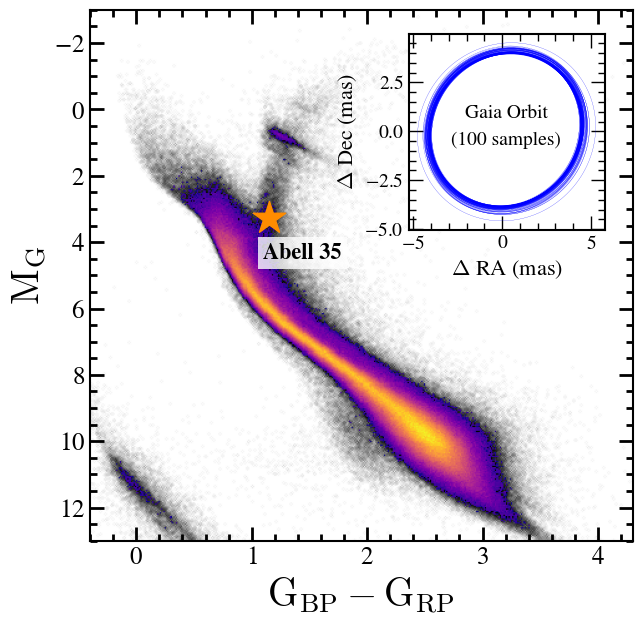

In [7]:
## Plot Figure


fig = plt.figure(figsize=(7, 7))
ax = GaiaCMDAxis(fig)
ax.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2)
ax.set_xlim(-0.4, 4.3)
ax.set_ylim(13, -3)
ax.scatter(1.15, 3.26, s=600, c='darkorange', marker = '*',zorder = 10000)


axins = fig.add_axes([0.58, 0.56, 0.28, 0.28])

random_draws = np.random.multivariate_normal(mu_vec_BH1, cov_mat_BH1, 100)


for i in range(random_draws.shape[0]):
    
    mu_vec_BH1_rand = random_draws[i]

    t_grid = np.linspace(0, mu_vec_BH1_rand[10]/365.25, 1000)
    x_curve, y_curve = photocenter_orbit_2d_from_thiele_innes(t_ast_yr = t_grid, 
                                                              parallax = mu_vec_BH1_rand[2], 
                                                              period = mu_vec_BH1_rand[10], 
                                                              Tp=mu_vec_BH1_rand[11], 
                                                              ecc = mu_vec_BH1_rand[9], 
                                                              A=mu_vec_BH1_rand[5], 
                                                              B=mu_vec_BH1_rand[6], 
                                                              F=mu_vec_BH1_rand[7], 
                                                              G=mu_vec_BH1_rand[8])
    axins.plot(x_curve, y_curve, ls='-', lw=0.15, color='b')
    
axins.tick_params(which='both',direction='in',top=True,right=True,labelsize=14,labelbottom = True, width=1, labelleft=True)

axins.set_ylabel(r'$\Delta$ Dec (mas)', fontsize = 16)
axins.set_xlabel(r'$\Delta$ RA (mas)', fontsize = 16)

axins.text(-2.1, 0.7, r'Gaia Orbit', fontsize = 14)
axins.text(-2.9, -0.7, r'(100 samples)', fontsize = 14)

ax.text(
    1.1, 4.5, 'Abell 35',
    color='k',
    fontsize=16,
    fontweight='bold',
    bbox=dict(
        facecolor='white',
        alpha=0.8,
        edgecolor='none'   # ← no border
    )
)

#plt.savefig("./plots/a35_paper_plots/a35_cmd_with_orbit.png",dpi=300,bbox_inches='tight')


In [8]:
'''Calculate Cunningham IFMR'''

def func_init_mass(mf, c1 = 0.469, c2 = 0.086, c1_err = 0.003, c2_err = 0.004, nsamples = 5000):
    
    c1_samples = np.random.normal(c1, c1_err, nsamples)
    c2_samples = np.random.normal(c2, c2_err, nsamples)
    mi_samples = (mf - c1_samples)/c2_samples
    
    return mi_samples, [np.median(mi_samples), np.percentile(mi_samples, 0.135, axis=0), np.percentile(mi_samples, 99.865, axis=0)],\
                        [np.median(mi_samples), np.percentile(mi_samples, 16.0, axis=0), np.percentile(mi_samples, 84.0, axis=0)]


In [9]:
'''
Calculate the dynamic mass
m1: float, Msun, (mass of luminous star)
m2: float, Msun, (mass of companion)
'''

def f_m1(m1g, m2, sma_lum_phys, eps, period):
    lhs = m1g + m2

    sma_phys_corr = sma_lum_phys / (m2/(m1g + m2) - eps/(1 + eps))

    rhs = (4 * np.pi**2 * sma_phys_corr**3) / (G * period**2) / msun

    return lhs - rhs

def get_m1_from_m2(m2, nrand = 5000, eps = 0.009, apply_eps_corr = True,
                  m1_grid = np.arange(0.1, 5, 0.001)):

    random_draws = np.random.multivariate_normal(mu_vec_BH1, cov_mat_BH1, nrand)

    m1s = []

    for i in range(random_draws.shape[0]):

        mu_vec_BH1_rand = random_draws[i]

        A=mu_vec_BH1_rand[5] 
        B=mu_vec_BH1_rand[6] 
        F=mu_vec_BH1_rand[7] 
        Gt=mu_vec_BH1_rand[8]

        S = A**2 + B**2 + F**2 + Gt**2
        D = A*Gt - B*F

        cosi = (S - np.sqrt((S**2) - 4*(D**2)))/(2*D)

        sma_lum = np.sqrt(D/cosi)

        period = mu_vec_BH1_rand[10] * 86400.0

        sma_lum_phys = sma_lum * (1000.0/mu_vec_BH1_rand[2]) * 3.086e18 * 4.84814e-9
        
        if apply_eps_corr:
            
            m1 = brentq(f_m1, 0.1, 5, args=(m2, sma_lum_phys, eps, period))
            
        else:

            mtot = np.sqrt( ( ((m2*msun)**3) * G * (period**2) ) / (4 * (np.pi**2) * ((sma_lum_phys)**3) ) )/msun

            m1 = mtot - m2
            
        m1s.append(m1)
            
        
    return m1s, np.median(m1s), np.percentile(m1s, 99.865), np.percentile(m1s, 0.135), np.percentile(m1s, 84.0), np.percentile(m1s, 16.0) 


In [10]:
mwds = np.linspace(0.53, 0.61, 100)

m1s_med = []
m1s_plus = []
m1s_minus = []

m1s_plus_1sig = []
m1s_minus_1sig = []

m1s_all = []

for m2i in trange(len(mwds)):
    
    m2 = mwds[m2i]
    
    func_init_mass
    
    m1s, med, med_plus, med_minus, med_plus_1sig, med_minus_1sig = get_m1_from_m2(m2)
    
    m1s_all = m1s_all + m1s
    
    m1s_med.append(med)
    m1s_plus.append(med_plus - med)
    m1s_minus.append(med - med_minus)
    m1s_plus_1sig.append(med_plus_1sig - med)
    m1s_minus_1sig.append(med - med_minus_1sig)
    
m1s_med = np.array(m1s_med)
m1s_plus = np.array(m1s_plus)
m1s_minus = np.array(m1s_minus)

100%|█████████████████████████████████████████| 100/100 [00:15<00:00,  6.64it/s]


In [13]:
init_med_masses = []
init_hi_masses = []
init_low_masses = []

init_hi_masses_1sig = []
init_low_masses_1sig = []

init_masses = []

for wd_mass in mwds:
    
    init_mass, init_mass_output, init_mass_output_1sig = func_init_mass(wd_mass)
    init_med_masses.append(init_mass_output[0])
    init_low_masses.append(init_mass_output[1])
    init_hi_masses.append(init_mass_output[2])
    
    init_low_masses_1sig.append(init_mass_output_1sig[1])
    init_hi_masses_1sig.append(init_mass_output_1sig[2])
    
    init_masses = init_masses + init_mass.tolist()
    
init_med_masses = np.array(init_med_masses)
init_low_masses = np.array(init_low_masses)
init_hi_masses = np.array(init_hi_masses)

init_low_masses_1sig = np.array(init_low_masses_1sig)
init_hi_masses_1sig = np.array(init_hi_masses_1sig)

init_masses = np.array(init_masses)

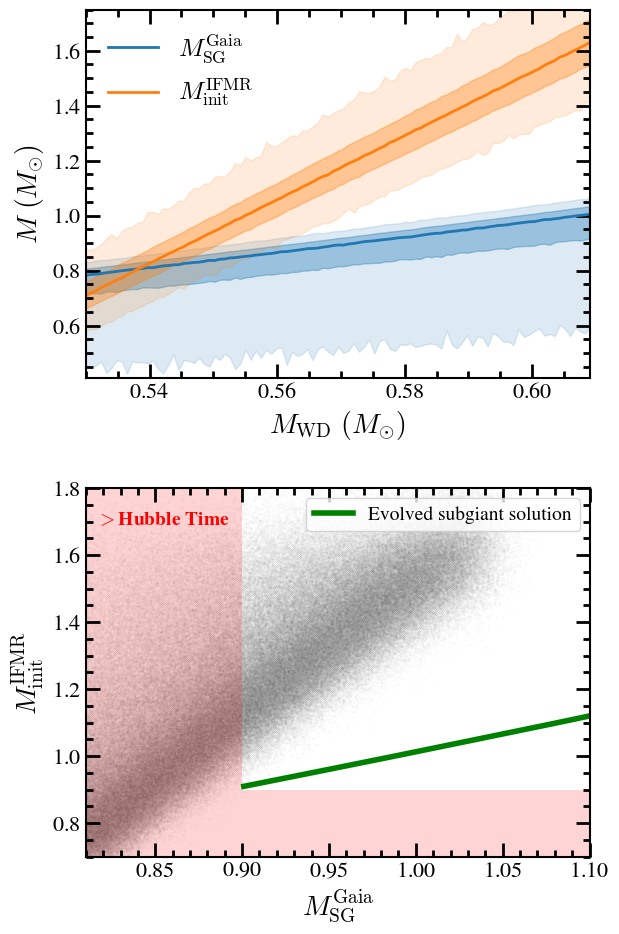

In [14]:
twin_csv = pd.read_csv('twin_solution_space.csv')

fig = plt.figure(figsize=(6.5, 11))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.3)

# ---------- Top panel ----------
ax1 = fig.add_subplot(gs[0])

ax1.plot(mwds, m1s_med, linewidth=2, label=r'$M_{\rm SG}^{\rm Gaia}$', c='C0')
ax1.fill_between(
    mwds,
    m1s_med + m1s_plus,
    m1s_med - m1s_minus,
    alpha=0.15,
    color='C0'
)

ax1.fill_between(
    mwds,
    m1s_med + m1s_plus_1sig,
    m1s_med - m1s_minus_1sig,
    alpha=0.35,
    color='C0'
)

ax1.plot(mwds, init_med_masses, c='C1', linewidth=2, label=r'$M_{\rm init}^{\rm IFMR}$')
ax1.fill_between(
    mwds,
    init_low_masses,
    init_hi_masses,
    alpha=0.15,
    color='C1'
)

ax1.fill_between(
    mwds,
    init_low_masses_1sig,
    init_hi_masses_1sig,
    alpha=0.35,
    color='C1'
)

ax1.set_xlim(0.53, 0.609)
ax1.set_ylim(0.41, 1.75)

ax1.tick_params(
    which='both', direction='in', top=True, right=True,
    labelsize=16, labelbottom=True, width=2, labelleft=True
)

ax1.set_ylabel(r'$M~(M_{\odot})$', fontsize=20)
ax1.set_xlabel(r'$M_{\rm WD}~(M_{\odot})$', fontsize=20)

ax1.legend(loc='upper left', framealpha=0, fontsize=18)


# ---------- Bottom panel ----------
ax2 = fig.add_subplot(gs[1])

ax2.scatter(m1s_all, init_masses, s=0.01, alpha=0.2, c='gray')

equal_plot = np.linspace(0.8, 1.3, 50)

equal_plot = np.linspace(0.901, 1.1, 50)
ax2.plot(equal_plot, np.interp(equal_plot, twin_csv['mass_subg'].values, twin_csv['mass_ifmr'].values), 
         c='green', linestyle='-', linewidth = 4, label = 'Evolved subgiant solution')

rect = Rectangle(
    (0.6, 0.5),          # (x_min, y_min)
    10,           # width
    0.9 - 0.5,           # height
    facecolor='red',
    alpha=0.17,
    edgecolor='none'
)

ax2.add_patch(rect)

rect = Rectangle(
    (0.6, 0.9),          # (x_min, y_min)
    0.9 - 0.6,           # width
    10,           # height
    facecolor='red',
    alpha=0.17,
    edgecolor='none'
)

ax2.add_patch(rect)

ax2.text(
    0.02, 0.9, r'$\mathbf{>}$Hubble Time',
    c='red', fontweight='bold', fontsize=14,
    transform=ax2.transAxes
)

ax2.set_xlim(0.81, 1.1)
ax2.set_ylim(0.7, 1.8)

ax2.tick_params(
    which='both', direction='in', top=True, right=True,
    labelsize=16, labelbottom=True, width=2, labelleft=True
)

ax2.set_ylabel(r'$M_{\rm init}^{\rm IFMR}$', fontsize=20)
ax2.set_xlabel(r'$M_{\rm SG}^{\rm Gaia}$', fontsize=20)

ax2.legend(loc='upper right', fontsize = 14)

#plt.savefig("./plots/a35_paper_plots/minit_msbg_compare_2.png",dpi=300,bbox_inches='tight')

plt.show()
